In [87]:
# Setup Cell: import all dependencies and define global constants

import marimo as mo

# standard/numerical
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Arc
import networkx as nx
import pandas as pd

# qiskit
# we avoid the pattern `from qiskit.submodule import Class` to make it clear in each cell where each function/class comes from
import qiskit
import qiskit.visualization
import qiskit_ibm_runtime
import qiskit_aer
from qiskit.exceptions import MissingOptionalLibraryError

# bosonic
import bosonic_sdk
from bosonic_converters import CircuitConverters # sufficiently self-explanatory

# filter warnings
import warnings
warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
)

# config constants
VERIFY_CFG = {
    'N_LIST': range(3, 21), # circuit sizes to sweep over
    'SHOTS': 2048, # number of times to simulate each circuit
    'SEED': 1234, # RNG seed to ensure reproducibility
}

SCALING_CFG = {
    'N_LIST': range(3, 128),
    'QUBITS_PER_TRAP': 32,
}

TTS_CFG = {
    'SHOTS': 1024,
    'N_LIST': range(5, 126, 5),
    'QUBITS_PER_TRAP': 128,
}

## Distributing a Circuit 

As we briefly touched upon in the previous tutorial, the real advantage of distributed architectures is **parallelism**: the ability to run different parts of a circuit at the same time on different processors. To realize this goal, we now care about more than just gate counts. We need an algorithm that will take a logical circuit and transform it into something that can be parallelized. To do this we need to keep track of which qubits interact with each other at every time step of the circuit. We then need to take this information and find an optimal mapping to QPUs in which qubits that interact with each other are kept close and parts of the circuit which are independent of each other can be executed at the same time. All this to say, distributing a circuit is no easy task.

To move forward, we will first provide a list of terminology used throughout the notebook and lay down some assumptions about the distributed architecture. These definitions will give us the language we need for talking about circuit distribution and setting up our problem. 

### Terminology 

Below is a glossary of terms used throughout this notebook.

- **Distributed Quantum Architecture (DQA):** A quantum system made of multiple connected QPUs that run one computation together.
- **Distributed Quantum Computing (DQC):** Executing one logical quantum circuit across multiple QPUs instead of on a single processor.
- **Quantum Processing Unit (QPU):** A quantum processor that stores qubits and executes gates locally.
- **Control Unit (CU):** Classical control hardware/software that coordinates operations across QPUs.
- **Local operation:** A gate applied to qubits that are on the same QPU.
- **Non-local operation (remote operation):** A gate that involves qubits located on different QPUs.
- **Bell pair / Ebit (entanglement bit):** A shared entangled two-qubit resource used to enable remote quantum operations.
- **Bell circuit:** A circuit that prepares a Bell state (maximally entangled 2-qubit state).
- **State teleportation:** Moving an unknown quantum state from one QPU to another using entanglement + classical communication.
- **Gate teleportation:** Implementing a gate remotely by consuming entanglement and using measurements/feed-forward.
- **Nearest-neighbor connectivity:** A constraint where two-qubit gates are only allowed between directly connected qubits.



To talk concretely about circuit distribution, we need to properly define what we are talking about when we talk about what a distributed quantum architecture (DQA) looks like.

At a high level, a DQA consists of multiple quantum processing units (QPUs) that can each run local gates on their own qubits, plus shared resources that let these QPUs coordinate and exchange quantum information. More formally, we can break this general DQA down into 4 main components: 

- **Multiple QPUs.**  
  Each QPU holds a number of *computational qubits* that store the input state of the circuit and its intermediate state. We assume we can prepare these qubits at the start of the computation and read them out by measurement at the end.

- **Classical communication network.**  
  QPUs are connected by a classical channel they can use to send measurement outcomes and receive correction instructions. This classical messaging is used, for example, to coordinate communication between QPUs via teleportation protocols.

- **Ebit (Entanglement Bit) generation hardware.**  
  An entanglement bit or *ebit* for short, is a maximally entangled two-qubit state shared between two different QPUs, typically taken to be a Bell state. Each half of the ebit is stored on a different QPU and can be consumed as a resource to teleport a qubit or to implement a non-local multi-qubit gate.

- **Ebit memory space.**  
  Each QPU has dedicated qubits used to store (and possibly generate) its halves of ebits. These ebit qubits may be realized in a different physical species or sub-register than the main workspace qubits, but they must be able to interact with workspace qubits via two-qubit gates so that entanglement can be spread within a QPU. 

Under this model, the main communication bottleneck in a distributed architecture is the creation and consumption of ebits across QPUs, which is often orders of magnitude more expensive than local two-qubit gates (often but not always!).

### Assumptions 

With our terminology defined, the next step is to talk about assumptions. There are different approaches to realizing a DQA, and each one comes with its own considerations. Since we want to keep this model general, we will not consider connectivity restrictions on ebit pairs between QPUs or connectivity restrictions within modules. We will also treat ebit generation as a black box. As a result, we assume that ebit pairs can be generated between any two QPUs, that communication qubits within modules can freely communicate with computation qubits within the module using two-qubit gates, and that we can ignore restrictions specific to a particular ebit generation scheme.  

With these definitions in place we can start to construct our distribution problem. In most DQAs ebit generation is the most expensive operation in a distributed quantum algorithm, followed by two-qubit gates and then single-qubit gates. Thus, our goal is to minimize ebit generation first, then minimize two-qubit gates. We will ignore single-qubit gates since these are not of particular interest and are easier to implement than the former. 


## Naive Distribution

Before we introduce more sophisticated distribution strategies, it is useful to talk about the simplest possible distribution strategy. A naive distributor assigns a fixed placement of logical qubits onto QPUs at the start of the circuit and never revisits that decision. In the simplest case, we fill the available QPU registers in order: the first block of qubits goes to the first QPU, the next block goes to the second, and so on.

Once the placement is fixed, every two-qubit gate is handled locally if both qubits live on the same QPU. If the two qubits live on different QPUs, the naive implementation inserts a new remote link for that gate. This is a reasonable baseline because it does exactly what the circuit asks for, but it does not try to reuse communication across nearby gates and it does not move qubits to reduce future communication.

The next cell shows the same tiny circuit twice: first as a regular monolithic Qiskit circuit, then as the naive distributed interpretation where fixed QPU placement determines which gates become remote links.


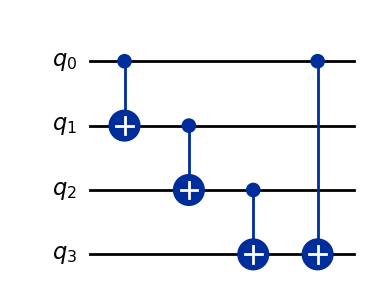

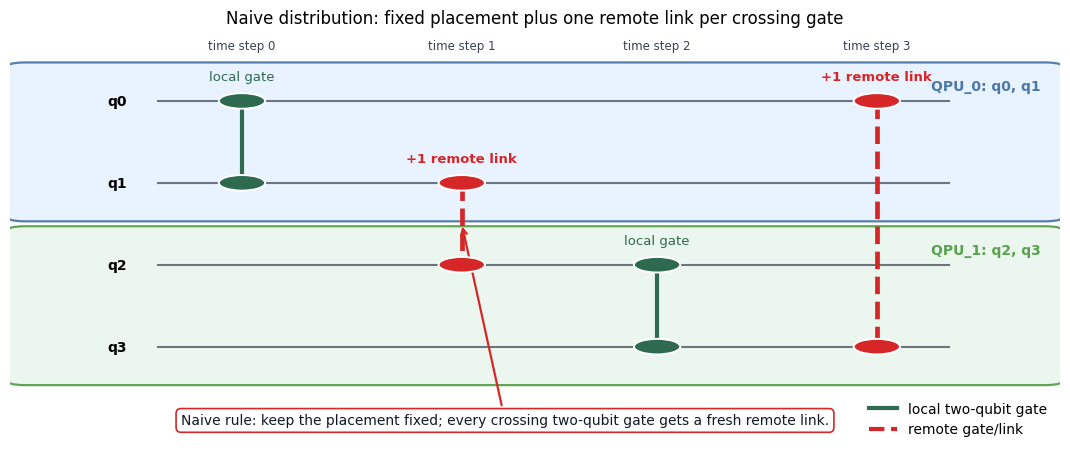

In [88]:
# Compare the ordinary circuit diagram with the naive distributed interpretation.
from IPython.display import display
import importlib
import qiskit
import Tutorial_Notebooks.Notebook_Utils.distribution_tutorial_utils as dtu

importlib.reload(dtu)

naive_logical_circuit = qiskit.QuantumCircuit(4, name='naive_baseline_example')
naive_logical_circuit.cx(0, 1)  
naive_logical_circuit.cx(1, 2)  
naive_logical_circuit.cx(2, 3)  
naive_logical_circuit.cx(0, 3)  

display(naive_logical_circuit.draw(output='mpl', fold=-1))
dtu.draw_naive_distribution_example()


## Graphs

This naive approach could work for small circuits, but it breaks down as we scale up. We can do much better. You may be familiar with graphs in computer science, but if you are not, or as a quick refresher, a graph is a set of $ N $ nodes connected via a set of $ E $ edges. Nodes are used to represent data points, and edges represent the connections between those data points. This formulation can be used to represent many useful scenarios. For example, one may represent airports as nodes and flights between airports as edges and use that to optimize travel itineraries, or represent locations in a city as nodes and roads as edges to build a navigation system. More relevantly, one could also represent qubits as nodes and use edges to represent connectivity within a given topology and use that to optimize circuit compilation. 

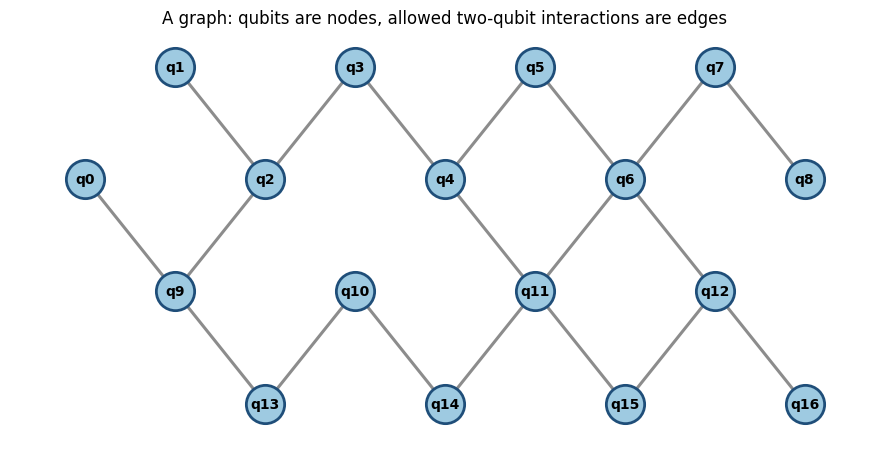

In [89]:
# A graph: qubits are nodes, allowed two-qubit interactions are edges.
# Reload the helper module so this cell works after editing the utilities without restarting the kernel.
import importlib
import Tutorial_Notebooks.Notebook_Utils.distribution_tutorial_utils as dtu

importlib.reload(dtu)

connectivity_graph, heavy_hex_pos = dtu.heavy_hex_connectivity_example()
dtu.draw_connectivity_graph(connectivity_graph, heavy_hex_pos)


This is what a connectivity graph of a heavy hex topology may look like with nearest-neighbor connectivity with some edges missing for demonstration purposes. With this graph we can now visualize what our connectivity may look like and even use it to partition a circuit. Say for example that our logical circuit requires us to do a swap gate between qubit 0 and qubit 16. Since we are limited by nearest-neighbor connectivity, we need to find the shortest path between the two. Fortunately, this is a common problem which has many well-defined methods for solving it.

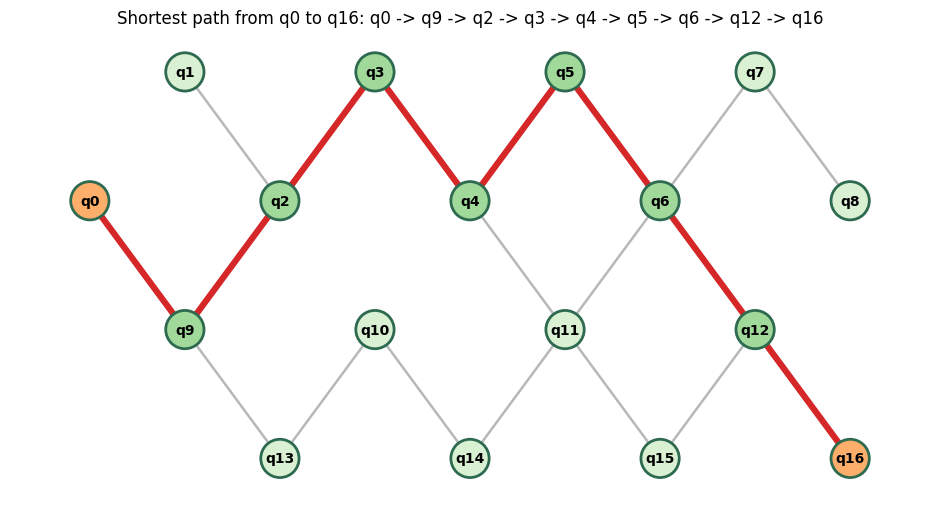

['q0', 'q9', 'q2', 'q3', 'q4', 'q5', 'q6', 'q12', 'q16']

In [90]:
# The same graph can be used for a shortest-path problem.
start, target = 'q0', 'q16'
shortest_path = dtu.draw_shortest_path_graph(connectivity_graph, heavy_hex_pos, start, target)
shortest_path


## Weights 

We can take this one step further by introducing the concept of weights. Going back to the navigation system example where locations are nodes and edges are the roads that connect them, what would we do if the shortest path has a lot of traffic and a longer route would get you there faster? In a quantum context, what if testing reveals that a communication link between a specific set of qubits is more prone to errors? Well we can introduce values to each edge that represent a "cost" related to that edge. We can then find the path that minimizes the cost rather than the total distance. 

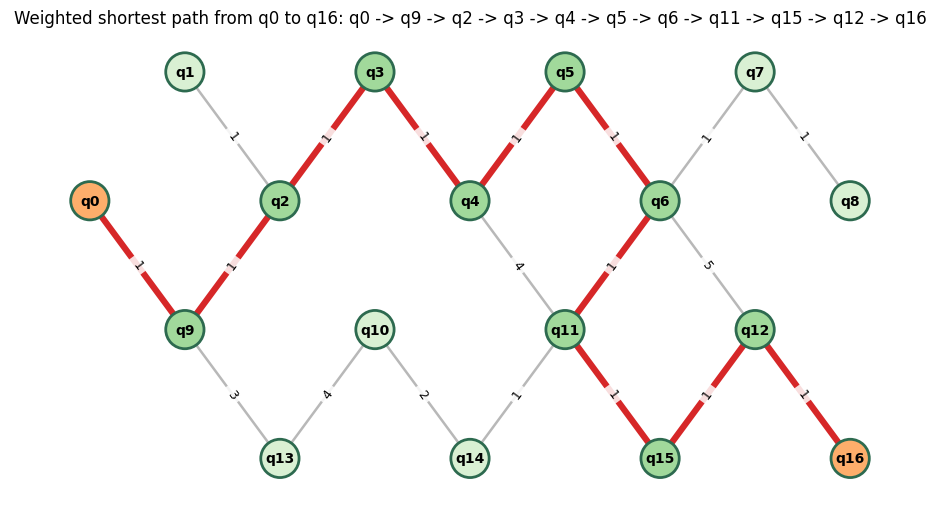

Weighted path cost: 10


['q0', 'q9', 'q2', 'q3', 'q4', 'q5', 'q6', 'q11', 'q15', 'q12', 'q16']

In [91]:
# Adding weights can change which path is shortest.
weighted_graph = dtu.weighted_heavy_hex_graph()
weighted_path, weighted_path_cost = dtu.draw_weighted_shortest_path_graph(
    weighted_graph,
    heavy_hex_pos,
    start,
    target,
)

print(f"Weighted path cost: {weighted_path_cost}")
weighted_path


Notice that the highlighted path which minimizes the cost is now longer than the shortest path from the first example. We could say here that the cost represents the amount of time that a gate takes to be implemented and now our graph tells us the fastest way we can execute a logical circuit on a given topology. This is a powerful tool for mapping circuits to real hardware, but it has a limitation. Each node is connected to another using exactly one edge. This means that we can only represent one relationship between nodes, in DQC we may have qubits that have more than just one relationship. For example, we may have qubits that are executed in the same time step AND are in the same QPU. Therefore, to extend this idea to DQC we need to be able to incorporate more variables. We can do this using **Hypergraphs**.

## Hypergraphs

In the graphs that we have been working with above each edge connects exactly two nodes. In a **hypergraph**, a single edge can connect any number of nodes at the same time. We call this more general kind of edge a **hyperedge** and the nodes are sometimes referred to as **vertices** in literature. Generally speaking, in an ordinary graph, an edge has the form $(u, v)$. In a hypergraph, a hyperedge can have the form $(u, v, w, \ldots)$. In diagrams hyperedges are represented as blobs containing the nodes they connect rather than straight lines, an example of what a hypergraph may look like is generated by the code below.


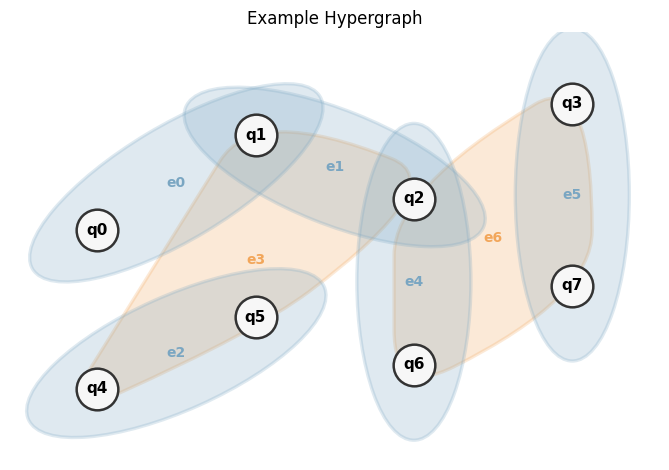

In [92]:
# Start by defining a set of hypergraph nodes and hyperedges.
hypergraph_nodes, hyperedges = dtu.example_hypergraph()
dtu.draw_hypergraph(hypergraph_nodes, hyperedges)


The picture draws each hyperedge $(e_n)$ as a blob around the nodes it contains. A two-node hyperedge is still a hyperedge, but instead of drawing it as a line, we draw it as a small rounded region containing both nodes. Larger hyperedges become larger regions. 

## Partitioning Hypergraphs

We now have a rough idea of what a hypergraph looks like and defined some basic properties, but by themselves they are not helpful for our goal of distributing a quantum circuit. To use hypergraphs we need to understand **partitioning**. 

Partitioning is the act of splitting the nodes of a hypergraph into groups. The goal is to make these groupings meaningful, that means that we want to put nodes that are tightly connected into the same group and keep nodes that don't interact in different groups. Generally speaking there are two main goals when partitioning a graph: 

1. Groups should remain balanced: no group should be too large or too small 
2. Minimize cuts: we want to keep hyperedges contained within single groups as much as possible 

A hyperedge is said to be **cut** if it ends up in a different group such as the diagram below: 

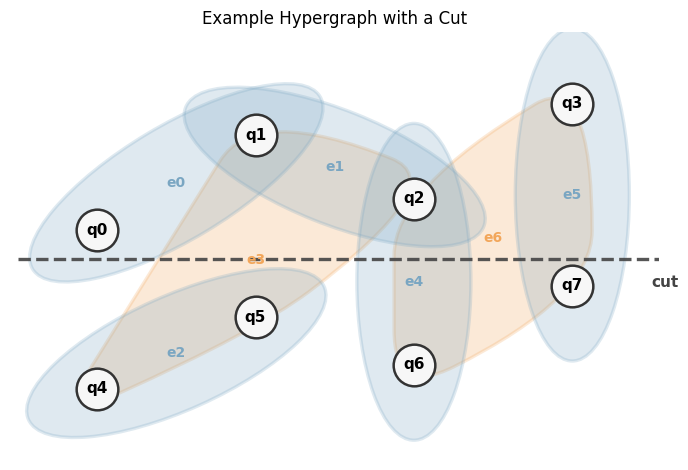

In [93]:
# Add a dashed line to the previous hypergraph.
dtu.draw_hypergraph(
    hypergraph_nodes,
    hyperedges,
    title='Example Hypergraph with a Cut',
    cut_line=((-0.5, 0.82), (4, 0.82)),
)


In the example above, we cut right through the middle and split edges $e_3 , e_4, e_5$ and $e_6$. This would be an example of a bad cut. With these two main constraints defined, we can define a function that captures what we care about and then minimize it. 

## Cost Functions

We can make the idea of a "good" or "bad" cut more precise by introducing the cost function. Cost functions are used to describe the goal of a problem and how well a trial state is performing with respect to that goal. Typically one wants to either minimize or maximize the cost function. Before defining a cost function in our given context we need to go into more detail about what happens when we partition a circuit. When we partition a hypergraph we split a vertex set $V$ into disjoint **groups**
$G_1, G_2, \dots, G_k$.  
In the context of distributing a circuit, each group corresponds to one QPU. 

For any hyperedge $e$, define
$$
P(e) = \{\, G_i \mid \text{hyperedge } e \text{ contains at least one vertex in group } G_i \,\}.
$$
$P(e)$ is the set of groups that hyperedge $e$ touches. For a very general case where we just count whether a hyperedge is cut or not, the cost of a partition $P$ looks something like:

$$
\mathrm{cost}(P) = \sum_{e \in E} \mathbf{1}(|P(e)| > 1)
$$


where $P(e)$ is the set of groups that hyperedge $e$ touches, and $\mathbf{1}$ is the indicator function: it returns 1 if the condition inside the bracket is true, and 0 otherwise. In words: for each hyperedge, check how many different groups it spans. If it stays in one group, the cost is 0. If it spans two or more groups, the cost is 1. 

$$
\mathbf{1}(|P(e)| > 1) =
\begin{cases}
1 & \text{if hyperedge } e \text{ is cut} \\
0 & \text{otherwise.}
\end{cases}
$$

This penalty is useful for minimizing cuts which is similar to finding the shortest path from the regular graphs earlier, but just like the graphs sometimes we want to value some hyperedges over others, so we add weights. To create a weight equivalent for the hypergraph case we replace the indicator function with a weight $w_e$ that represents the weight or cost of cutting hyperedge $e$.

$$
\mathrm{cost}(P) = \sum_{e \in E} w_e\mathbf{1}(|P(e)| > 1)
$$

With this weighted cost function we can attach a higher cost to more important hyperedges. When we go and optimize this function we can have high weights for hyperedges representing conditions that should never be violated and return realistic solutions. 

The optimization of hypergraph partitioning is considered to be an NP-hard problem. An NP-hard problem is defined as a computational problem that is at least as hard as the hardest problems in NP (Nondeterministic Polynomial time). In plainer terms, it means that the time it takes to solve the problem scales exponentially. Luckily the problem of hypergraph partitioning is one that has been widely studied and heuristics exist to optimize these cost functions that we can simply port over. 

## Mapping Circuits to Hypergraphs

We now have all the tools we need to connect the dots on how we can partition circuits to be executed on a general DQA. There are a few approaches to partitioning circuits but at the time of writing the state-of-the-art solution is given by the DisQCO (Distributed Quantum Circuit Optimization) algorithm by Felix Burt, Kuan-Cheng Chen, and Kin K. Leung. [Forrer et al., 2026]

DisQCO does this in two main steps:

1. Build a **temporal graph** (a graph that represents both time and qubit) from the circuit.
2. Turn that temporal graph into a **hypergraph**.

The big idea is simple:

- Nodes represent "qubit $q$ at time step $t$",
- Nodes can now interact in two ways: they could be executed in the same time step, or they could be connected via a two-qubit gate. This means we now have two types of edges $E_s$ and $E_g$. 
- Lastly, groups of compatible interactions are bundled together into a single hyperedge.

Under this mapping, each hyperedge grouping tells us which qubits can be executed on the same QPU. Once we have this hypergraph, partitioning the circuit becomes a standard hypergraph partitioning problem in which we assign nodes to QPUs while trying to cut as few important hyperedges as possible. 



### Creating a Temporal Graph from a Circuit

The first step in partitioning a circuit is to create a temporal graph from the logical circuit. A temporal graph is just a graph like the ones we saw earlier with a time dependence. To add time dependence we introduce the idea of **bipartite nodes**. This just means that instead of our nodes just representing a qubit they now represent a qubit at a given time step $v_q^{(t)}$. To create a temporal graph we follow 3 main steps. Below we define a toy circuit and walk through each step with a guided example. 


1. First, we need to transpile our circuit into a given gate set. These are the gate sets that are executable by a given hardware architecture. In this example we make a wise choice and use controlled-phase gates and phase gates for single-qubit gates. Every single-qubit gate can be represented as a rotation around the Bloch sphere. Since every gate is a rotation, we can combine those rotations and rotate our qubit once rather than once per single-qubit gate. This drastically cuts down on computational overhead. 

Original operations: {'cp': 3, 'rz': 1, 'rx': 1}
DISQCO-normalized operations: {'cp': 3, 'u': 2}


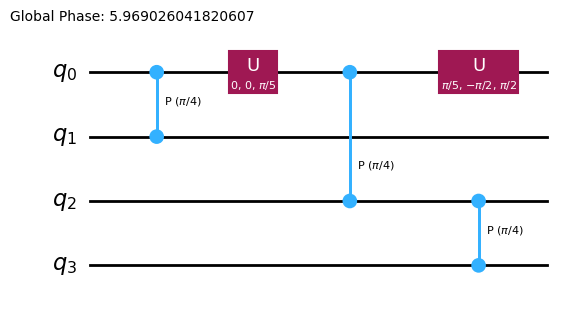

In [94]:
from bosonic_sdk.distributor.distributors.disqco_distributor import DisqcoDistributor


walkthrough_logical = qiskit.QuantumCircuit(4, name='disqco_walkthrough')
walkthrough_logical.cp(np.pi / 4, 0, 1)
walkthrough_logical.rz(np.pi / 5, 0)
walkthrough_logical.cp(np.pi / 4, 0, 2)
walkthrough_logical.rx(np.pi / 5, 0)
walkthrough_logical.cp(np.pi / 4, 2, 3)

walkthrough_normalized = DisqcoDistributor._normalize_for_disqco(walkthrough_logical)
print('Original operations:', dict(walkthrough_logical.count_ops()))
print('DISQCO-normalized operations:', dict(walkthrough_normalized.count_ops()))
walkthrough_normalized.draw('mpl', fold=-1)


2. To add time dependence we now add a bipartite node for each qubit at each time step. Our transpiled circuit has depth $d$. For each qubit $q$ and each time step $t \in \{1,\dots,d\}$ we create a node $v_q^{(t)}$. Instead of drawing one continuous horizontal wire per qubit, we now have a row of nodes along that wire, one for each time step. 




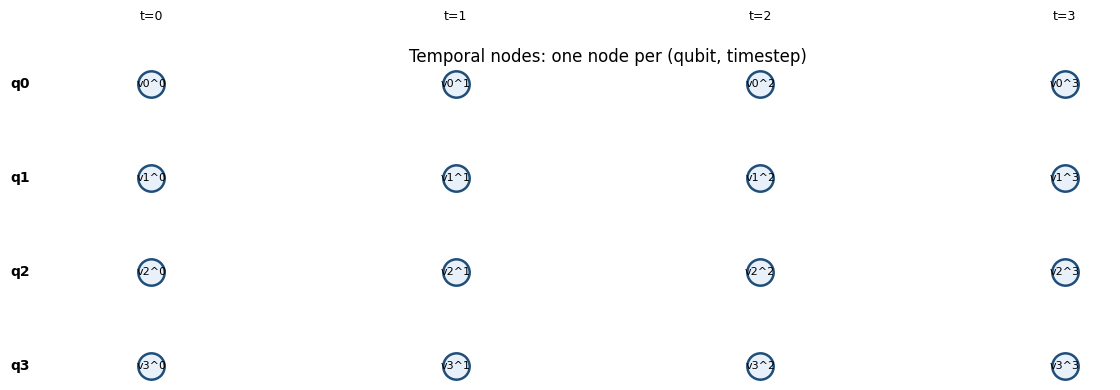

,t,ops
0,0,"cp(q0, q1, 0.785)"
1,1,"u(q0, 0, 0, 0.628)"
2,2,"cp(q0, q2, 0.785)"
3,3,"cp(q2, q3, 0.785); u(q0, 0.628, -1.57, 1.57)"


In [95]:
# Step 2: create temporal nodes (q, t) from the same layer representation DISQCO uses.
# Reload here too so this section works even if you jump straight to the DISQCO walkthrough.
import importlib
import Tutorial_Notebooks.Notebook_Utils.distribution_tutorial_utils as dtu

importlib.reload(dtu)

walkthrough_layers = dtu.disqco_layers(walkthrough_normalized)
temporal_num_qubits = walkthrough_normalized.num_qubits
temporal_depth = len(walkthrough_layers)
temporal_nodes = dtu.make_temporal_nodes(temporal_num_qubits, temporal_depth)
temporal_pos = dtu.temporal_positions(temporal_nodes)

temporal_node_graph = dtu.draw_temporal_nodes(
    temporal_nodes,
    temporal_pos,
    temporal_num_qubits,
    temporal_depth,
)
layer_summary_df = dtu.layer_summary_table(walkthrough_layers)
layer_summary_df


3) Once the nodes are in place, we add two kinds of edges.

- **State edges** $E_s$: connect the same qubit across adjacent time steps. For each qubit $q$ and each $t$, we add an edge between $v_q^{(t)}$ and $v_q^{(t+1)}$. These edges help us keep track of our logical qubits as we evolve in time. 

- **Gate edges** $E_g$: connect two qubits whenever there is a two-qubit gate between them at that time step. For each two-qubit gate on $(q_i,q_j)$ at time $t$, we add an edge between $v_{q_i}^{(t)}$ and $v_{q_j}^{(t)}$.

The resulting temporal graph already gives us a useful picture of the circuit:

- cutting a **state edge** corresponds to moving a qubit’s state to a different QPU. 
- cutting a **gate edge** corresponds to implementing that interaction via a remote gate.

So the temporal graph is the first bridge between the circuit diagram and a communication-cost model.


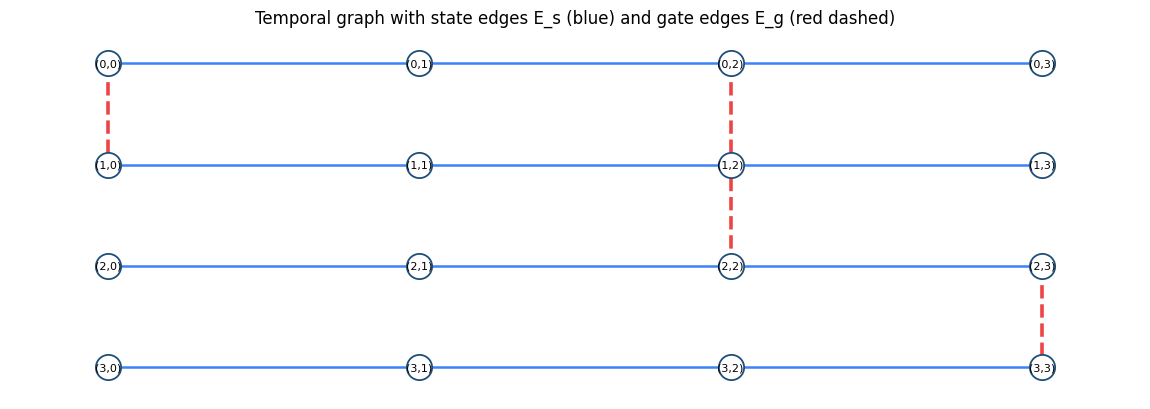

,t,gate,q_i,q_j
0,0,cp,0,1
1,2,cp,0,2
2,3,cp,2,3


In [96]:
# Step 3: add E_s (state) and E_g (gate) edges to the pedagogical temporal graph.
temporal_graph, state_edges, gate_edges, gate_events = dtu.build_temporal_graph(
    temporal_nodes,
    walkthrough_layers,
    temporal_num_qubits,
    temporal_depth,
)
dtu.draw_temporal_graph(temporal_graph, temporal_pos, temporal_nodes, state_edges, gate_edges)

pd.DataFrame(gate_events)


### Building a hypergraph from a temporal graph

We've built our temporal graph, the next step is to map it to a hypergraph. Recall the naive distributed strategy, whenever we see a two‑qubit gate whose endpoints sit in different QPUs, we simply plug in a remote‑link protocol at that point in the circuit. This works, but it clearly wastes communication in cases where a single remote link could support multiple two‑qubit gates in a row.

The key idea in DISQCO is to reuse a single entanglement link for many compatible remote gates instead of paying for a new link every time. If the same qubit acts as the control for a sequence of two‑qubit gates, and the single‑qubit gates on that qubit in between are only phase‑type operations, then all of those gates can be covered by one shared teleportation process rather than a sequence of separate ones. In other words, DISQCO looks for stretches of the circuit where one qubit repeatedly interacts with others in a way that is compatible with gate teleportation, and treats that whole stretch as a single chunk when deciding where entanglement is needed. The "same" qubit acting as a control in a sequence of two-qubit gates is referred to as a **root** qubit. The DisQCO algorithm then defines a set of rules that say when a set of gates can be treated as a single chunk along a shared root qubit.  



Before we state the rules, we need a bit of terminology.

- **Root and receiver qubits.** When we teleport a state from one QPU to another, we do so by creating an ebit between a pair of communication qubits and running a teleportation protocol. The qubit whose state is sent is the **root**; the qubit that receives that state is the **receiver**. Later, when we talk about grouped gates, the root is the qubit whose state is being moved around, and the receivers are the other qubits it interacts with during that episode.

- **Root set** $e_{\mathrm{root}}$.  
  This is the set of nodes corresponding to the root qubit over the full time interval covered by the group:
  $$
  e_{\mathrm{root}} = \{(q_{\mathrm{root}}, t_{\min}), \dots, (q_{\mathrm{root}}, t_{\max})\}.
  $$
  Intuitively, this tracks where the “main” qubit lives during the communication episode.

- **Receiver set** $e_{\mathrm{rec}}$.  
  This is the set of nodes where the grouped two-qubit gates touch the *other* qubits:
  $$
  e_{\mathrm{rec}} = \{(q_i, t_i) : \text{the grouped gate at time } t_i \text{ acts between } q_{\mathrm{root}} \text{ and } q_i\}.
  $$
  These are the qubits that need to interact with the root while that episode is taking place.

- **Diagonal / anti-diagonal single‑qubit gates on the root.** In this framework, the native two‑qubit gate is chosen to be a controlled‑phase type gate. In this basis, some single‑qubit gates on the root are especially convenient: those that are **diagonal or anti‑diagonal**. Diagonal gates only add phases in the computational basis, and anti‑diagonal gates swap the basis states up to phases. In both cases, these operations either commute with the controlled‑phase gate or turn it into another gate of the same family. That means we can slide them to the beginning or end of the teleportation block, or absorb them into the teleportation protocol, without changing which two‑qubit interactions we need to perform.

Very roughly, a set of two‑qubit gates is **teleportation‑compatible** if:

1. All gates share a common root qubit.
2. They appear contiguously along that root in time (no incompatible gates appear during the interval).
3. Any single‑qubit gates on the root between these two‑qubit gates are diagonal or anti‑diagonal in the chosen basis, so they do not break the teleportation pattern.



Given these criteria, the grouping algorithm scans the temporal graph forward in time. As long as we keep seeing compatible gates on a given root qubit, we extend the current group. When we encounter an incompatible gate on that root (for example, a two‑qubit gate that touches a different root, or a single‑qubit gate on the root that is not diagonal/anti-diagonal), we close the current group and, if needed, start a new one.



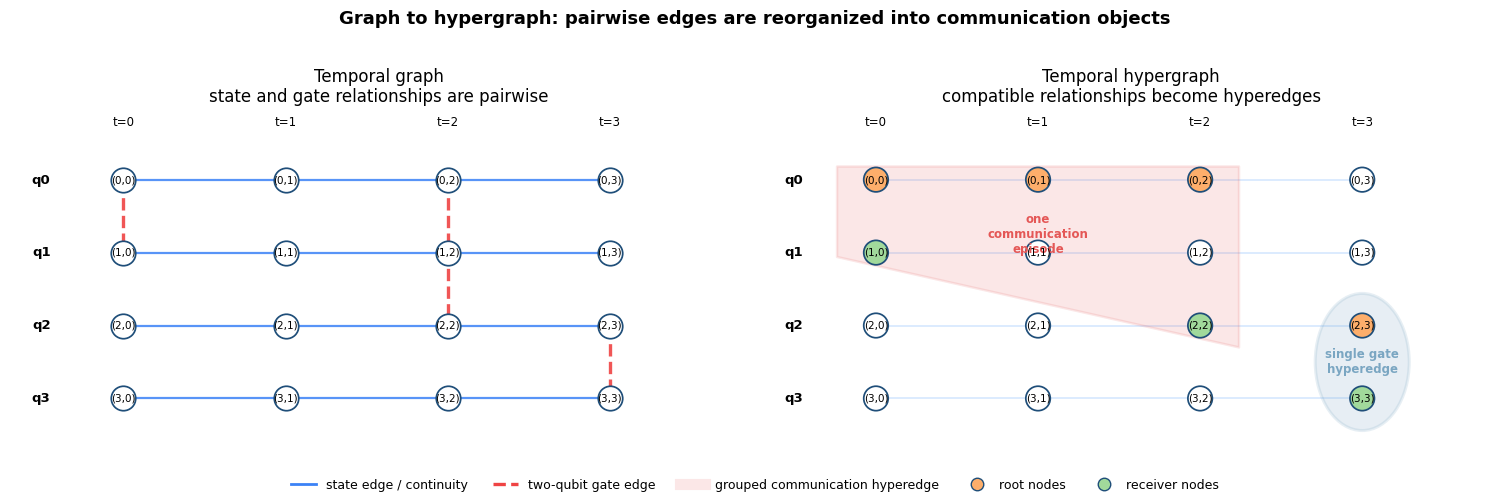

In [97]:
# Step 3b: visual bridge from the temporal graph to the temporal hypergraph.
# Left: pairwise temporal graph edges. Right: the same time/qubit nodes grouped into hyperedges.
preview_disqco_graph, preview_hyperedges, visible_hyperedges = dtu.preview_temporal_hyperedges(
    walkthrough_normalized
)
dtu.draw_graph_to_hypergraph_bridge(
    temporal_graph,
    temporal_pos,
    temporal_nodes,
    state_edges,
    gate_edges,
    visible_hyperedges,
    temporal_num_qubits,
    temporal_depth,
)


This is easier to understand using a visual. Taking a look at the temporal graph we had before on the left, we can see that the two-qubit gates at t=0 and t=2 both come from the same root qubit (qubit 0). This means that they can be grouped together as one communication episode. After that, the next two-qubit gate is at t=3 where qubit 2 is the root qubit and qubit 3 is the receiver. This is incompatible with the rules and thus the communication episode is cut off there and a new communication episode is started. 

## Real QASM Benchmark Example

Up to this point we've been using a tiny circuit because the goal was visual intuition. Now we switch to a benchmark-style circuit where the partitioner has a chance to do something nontrivial. The default example is `knn_n25`, a 25-qubit QASM benchmark whose naive static placement cuts many communication episodes. Feel free to choose another QASM circuit by editing `QASM_BENCHMARK_KEY` in the code cell below.

One practical notebook note: after changing the benchmark, rerun this section from the loading cell through the partitioning cell. Otherwise the live kernel may still hold the hypergraph from the previous circuit.


In [98]:
from pathlib import Path

from Tutorial_Notebooks.Notebook_Utils.distribution_tutorial_utils import benchmark_overview_table, load_disqco_benchmark

QASM_BENCHMARK_KEY = 'knn_n25'
LOCAL_QASM_PATH = Path('experiments/qasmbench/knn_n25.qasm')

benchmark = load_disqco_benchmark(QASM_BENCHMARK_KEY, LOCAL_QASM_PATH)
benchmark_circuit = benchmark.circuit
benchmark_original_stats = benchmark.original_stats
benchmark_qiskit = benchmark.qiskit_circuit
benchmark_normalized = benchmark.normalized_circuit
walkthrough_layers = benchmark.layers
temporal_num_qubits = benchmark.num_qubits
temporal_depth = benchmark.temporal_depth
temporal_nodes = benchmark.temporal_nodes

print(f'Loaded {benchmark.key} from {benchmark.source}')
print(f"Logical qubits: {benchmark_original_stats['n_qubits']}")
print(f"Original operations: {benchmark_original_stats['total_ops']}")
print(f"Original depth: {benchmark_original_stats['depth']}")


Loaded knn_n25 from qasmpi:knn_n25
Logical qubits: 25
Original operations: 38
Original depth: 15


### Circuit as a Hypergraph

In the previous example, we stopped once the circuit had been translated into a temporal hypergraph. For the QASM benchmark, we pick up where we left off by letting DisQCO turn our QASM Circuit into a hypergraph.


In [99]:
# Build the actual DISQCO temporal hypergraph for the benchmark circuit.
from disqco import QuantumCircuitHyperGraph
from Tutorial_Notebooks.Notebook_Utils.distribution_tutorial_utils import grouped_layer_tables

disqco_graph = QuantumCircuitHyperGraph(benchmark_normalized, group_gates=True)
grouped_layer_df, layer_type_summary_df, largest_grouped_objects_df = grouped_layer_tables(disqco_graph)

print(f'DISQCO hypergraph nodes: {len(disqco_graph.nodes)}')
print(f'DISQCO hyperedges: {len(disqco_graph.hyperedges)}')
print(f'Layer objects after grouping: {len(grouped_layer_df)}')
layer_type_summary_df


DISQCO hypergraph nodes: 2550
DISQCO hyperedges: 2562
Layer objects after grouping: 122


,type,objects,layers_touched,total_subgates,largest_object
0,group,37,15,133,61
1,single-qubit,85,50,85,1


### Partitioning the Hypergraph

Now that the circuit is represented as a hypergraph, the distribution problem becomes a partitioning problem. This is where the hypergraph representation starts to pay off. A grouped hyperedge can represent a whole communication episode: one root qubit interacting with one or more receiver qubits over a stretch of time. If that whole episode can be kept local, we pay no remote communication. If the receivers live on QPUs not already covered by the root, DISQCO has to pay for remote entanglement.

Mathematically, the partition is written as an assignment function:

$$
\Phi: V \to \mathcal{Q},
\qquad
\Phi(q,t) = QPU_i.
$$

Here $V$ is the set of temporal nodes and $\mathcal{Q}$ is the set of available QPUs. The solver's job is to choose $\Phi$; the cost function tells us how good that choice is.

For a hyperedge $e$, DISQCO separates the temporal nodes into a root set and a receiver set:

$$
R_e = \{\Phi(v) : v \in e_{\mathrm{rec}}\},
\qquad
S_e = \{\Phi(u) : u \in e_{\mathrm{root}}\}.
$$

Using that assignment, $S_e$ is the set of QPUs touched by the root part of the episode, and $R_e$ is the set of QPUs touched by the receiver part. For a two-QPU all-to-all model we use here, the cost of that hyperedge is

$$
c_e(\Phi) = |R_e \setminus S_e|.
$$

The truth table below is meant to clarify how the cost function works:

| Root QPUs $S_e$ | Receiver QPUs $R_e$ | Cost | Intuition |
| --- | --- | ---: | --- |
| ${QPU_0}$ | ${QPU_0}$ | 0 | the episode is local |
| ${QPU_0}$ | ${QPU_1}$ | 1 | one remote link is needed |
| ${QPU_0, QPU_1}$ | ${QPU_1}$ | 0 | the receiver QPU is already covered by the root path |

The solver is therefore looking for an assignment $\Phi$ that keeps compatible communication episodes local when possible and reduces the number of new remote-entanglement links required by the circuit. It also has to respect the hardware size constraint: at each time step, a QPU cannot hold more logical states than its capacity allows.

The next step is to run an optimizer to minimize the cost function. DISQCO uses a multilevel version of the Fiduccia-Mattheyses (FM) partitioning heuristic to search for this assignment. Going over the specifics of the Fiduccia-Mattheyses heuristic is outside the scope of this tutorial, but if you are interested in learning more refer to [Burt et al., 2026].


In [100]:

# Partition the benchmark hypergraph and summarize communication demand.
from Tutorial_Notebooks.Notebook_Utils.distribution_tutorial_utils import benchmark_partition_summary

partition_summary = benchmark_partition_summary(
    benchmark,
    disqco_graph,
    expected_key='knn_n25',
    qpu_sizes={'QPU_0': 13, 'QPU_1': 13},
)

remote_link_summary_display_df = partition_summary.remote_link_summary_display_df
remote_link_summary_display_df


,assignment,remote_two_qubit_gates,cut_gate_or_group_episodes,total_hypergraph_cost
0,DISQCO partitioned,24,1,1
1,naive static baseline,72,37,37
2,DISQCO initial,72,37,37


### Reading the Partition

In the table above we compare three assignment strategies: the naive distribution strategy, DISQCO's initial placement, and the placement after partitioning. 

- `remote_two_qubit_gates` counts the raw two-qubit gates whose endpoints live on different QPUs.
- `cut_gate_or_group_episodes` counts the grouped communication episodes that actually require remote entanglement.

As we can see, the naive implementation would require 37 more remote entanglement links. Even for a smaller circuit, that makes the distributed execution drastically more expensive. 

### From Partition to Lowered Circuit

At this point the last step is simply to map the partitioned hypergraph back to a circuit. To do so, we use the **assignment matrix**. The rows are time layers, the columns are logical qubits, and each entry is the index of the QPU that holds that logical qubit at that moment of the circuit.

This is the matrix form of the assignment function from above:

$$
A_{t,q}=i \quad \Longleftrightarrow \quad \Phi(q,t)=\mathrm{QPU}_i.
$$

Reading across a row tells us the whole circuit placement at one layer. Reading down a column gives one qubit's path through the architecture. If a column changes from one QPU to another, that means the partition has decided to move that qubit's state between QPUs.

The `knn_n25` benchmark above happens to have a static optimized assignment. That is useful for communication grouping, but it does not show what a moving column looks like. In some cases it is less expensive to move a qubit state to another QPU and then execute the same circuit. To make this behavior visible, the next cell switches to a larger-in-depth synthetic handoff circuit: a hub qubit interacts with one cluster first, then with another cluster later. With tight two-QPU capacity, it becomes cheaper to move that hub qubit once than to keep paying remote-gate costs.


In [101]:

# Build a deeper state-move example, then lower the optimized assignment.
from IPython.display import display
from Tutorial_Notebooks.Notebook_Utils.distribution_tutorial_utils import (
    print_lowered_circuit_summary,
    print_state_move_demo_summary,
    run_state_move_demo,
)

state_move_demo = run_state_move_demo(
    num_qubits=25,
    repetitions=60,
    qpu_sizes={'QPU_0': 13, 'QPU_1': 13},
)

print_state_move_demo_summary(state_move_demo)
print()
print('Remote demand summary:')
display(state_move_demo.remote_summary_df)
print('Moving qubits in the optimized assignment:')
display(state_move_demo.moving_qubits_display_df)
print_lowered_circuit_summary(
    state_move_demo.lowered_circuit,
    state_move_demo.lowered_runtime_s,
)
state_move_demo.lowered_count_display_df


State-move demo circuit:
  logical qubits: 25
  temporal layers: 240
  normalized operations: {'cp': 120, 'u': 120}

Remote demand summary:


,assignment,remote_two_qubit_gates,cut_gate_or_group_episodes,state_moves,total_hypergraph_cost
0,DISQCO partitioned,0,0,1,1
1,naive static baseline,60,12,0,12
2,DISQCO initial,60,12,0,12


Moving qubits in the optimized assignment:


,qubit,start_qpu,end_qpu,moves,compressed_path
0,q0,QPU_0,QPU_1,1,QPU_0 -> QPU_1


Lowered circuit registers:
  qregs: [('Q0_q', 13), ('C0_0', 1), ('Q1_q', 13), ('C1_0', 1)]
  cregs: [('cl', 25), ('result', 25)]
Lowered extraction runtime: 0.006 s


,operation,count
0,cp,120
1,u,120
2,measure,26
3,reset,2
4,EPR,1
5,Ending Process,1
6,cx,1
7,wrapper instruction,1
8,x,1


Here we have three levels of description happening back-to-back. Together, they give us a clear picture of the cost of distributing the synthetic circuit in terms of gate counts. They tell us which qubits move between QPUs, and which qubits are assigned to which QPUs. With this information we can now inform a control system used to control hardware and execute the distributed circuit on a given architecture. At the time of writing, this is the state-of-the-art solution to distributing a quantum circuit. Of course other methods exist. Below you will find code that generates a comparison table between another popular partitioning algorithm and a monolithic system, comparing the number of operations needed for a series of QASM circuits. 

In [102]:

from pathlib import Path
from IPython.display import Markdown, display
from Tutorial_Notebooks.Notebook_Utils.distribution_tutorial_utils import load_dqcomp_summary_table

DQCOMP_README = Path('/Users/felixvelasquez/dqcomp/README.md')

dqcomp_summary_df, dqcomp_summary_markdown = load_dqcomp_summary_table(DQCOMP_README)
display(Markdown(dqcomp_summary_markdown))


| Circuit         | Bosonic Remote | Hypergraph Remote | DISQCO Remote | Bosonic Ops | Hypergraph Ops | DISQCO Ops | IBM HeavyHex Ops |
|-----------------|----------------:|-------------------:|---------------:|-------------:|----------------:|------------:|------------------:|
| QuGAN (395)     |            747 |              1398 |             5 |       20331 |          22808 |       7099 |            14991 |
| QFT (320)       |            380 |               202 |            40 |       74340 |          49258 |      60420 |           315271 |
| QFT (160)       |            380 |               470 |            40 |       37540 |          27190 |      28260 |            82627 |
| BV (140)        |             36 |                 1 |             1 |         793 |            506 |        222 |              650 |
| Adder (118)     |            486 |                11 |             2 |        8998 |           3945 |       1742 |            12375 |
| W-State (118)   |              2 |                 2 |             2 |        1421 |           1190 |        479 |             2019 |
| QuGAN (111)     |            272 |                77 |             5 |        6165 |           3535 |       1987 |            11867 |
| QV (100)        |           7479 |              3326 |          2050 |      163777 |         104209 |      56999 |           588964 |
| Swap Test (83)  |            200 |                77 |             1 |        3447 |           2007 |        745 |             4871 |
| W-State (76)    |              2 |                 2 |             1 |         917 |            770 |        308 |             1053 |
| Multiplier (75) |            960 |               478 |            43 |       48051 |          32776 |      14562 |           127624 |
| QuGAN (71)      |            172 |                75 |             5 |        3905 |           2477 |       1267 |             7466 |
| BV (70)         |             17 |                 1 |             1 |         389 |            258 |        114 |             1396 |
| Adder (64)      |            264 |                11 |             2 |        4864 |           2169 |        944 |             6768 |
| QFT (63)        |            380 |               491 |            19 |       15230 |          12538 |       8658 |            67636 |
| DNN (51)        |            120 |                31 |             6 |        2759 |           1561 |        847 |             4626 |
| GHZ (40)        |              1 |                 1 |             1 |         204 |            205 |         45 |              300 |
| Ising (34)      |              2 |                 2 |             1 |         429 |            332 |        204 |              528 |
| Adder (28)      |            106 |                 9 |             2 |        2028 |            967 |        412 |             2638 |
| KNN (25)        |             55 |                21 |             1 |         982 |            575 |        223 |             1196 |
| Swap Test (25)  |             55 |                21 |             1 |         982 |            575 |        223 |             1225 |
| QRAM (20)       |             32 |                26 |             8 |        1070 |            830 |        334 |             2201 |
| QFT (18)        |            144 |                82 |             6 |        3006 |           1980 |        813 |             4505 |
| SQRT (18)       |            447 |               130 |            34 |        9182 |           4978 |       2184 |            14409 |

## References

[Burt et al., 2026] F. Burt, K.-C. Chen, and K. K. Leung, "A Multilevel Framework for Partitioning Quantum Circuits," *Quantum* 10, 1984, 2026, arXiv:2503.19082.